Import Libraries

In [258]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

Read Data

In [259]:
# =========================================
# READ DATA FROM EXCEL
# =========================================

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_R05.xlsx"   # ganti sesuai nama file Anda

# Generator data
gen_df = pd.read_excel(file_path, sheet_name="Gen")

# Demand data
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Jika data tidak diisi
#gen_df['Droop'] = gen_df['Droop'].fillna(0.0)
#gen_df['PFR_Fraction'] = gen_df['PFR_Fraction'].fillna(0.0)
#gen_df['FreeGovernor'] = gen_df['FreeGovernor'].fillna(0).astype(int)

# Tampilkan untuk cek
print(gen_df.head())
print(demand_df.head())

  Unit            Type  Pmin  Pmax  a      b      c  SU_Cost  SD_Cost  \
0   G1            Coal    40   300  0   4.22  50.00      800      500   
1   G2             Gas    50   200  0  10.40  60.70      500      200   
2   G3          Diesel    20   100  0  12.25  23.50      200       80   
3   G4  Combined-Cycle    80   150  0   8.75  40.72      300      200   
4   G5     Gas Machine    70   150  0   9.00  32.22      300      120   

   Ramp_Up  Ramp_Down  Min_Up  Min_Down  Droop  PFR_Fraction  FreeGovernor  \
0      150         50       8         6   0.05          0.15             1   
1      100        100       2         2   0.04          0.20             1   
2       80         80       1         1   0.05          0.20             1   
3       70         70       6         4   0.04          0.15             1   
4       80         80       1         1   0.04          0.20             1   

     H    Tg  
0  6.0  0.45  
1  4.0  0.30  
2  2.5  0.20  
3  5.0  0.35  
4  3.5  0.25  
  

Data Frame

In [260]:
# ============================
# CONVERT DATAFRAME → DICTIONARY
# ============================

# Set generator
G = gen_df['Unit'].tolist()

# Set time
T = demand_df['Hour'].tolist()

# Parameter generator
Pmin = dict(zip(gen_df['Unit'], gen_df['Pmin']))
Pmax = dict(zip(gen_df['Unit'], gen_df['Pmax']))
a = dict(zip(gen_df['Unit'], gen_df['a']))
b = dict(zip(gen_df['Unit'], gen_df['b']))
c = dict(zip(gen_df['Unit'], gen_df['c']))

SU_cost = dict(zip(gen_df['Unit'], gen_df['SU_Cost']))
SD_cost = dict(zip(gen_df['Unit'], gen_df['SD_Cost']))

RampUp = dict(zip(gen_df['Unit'], gen_df['Ramp_Up']))
RampDown = dict(zip(gen_df['Unit'], gen_df['Ramp_Down']))

MinUp = dict(zip(gen_df['Unit'], gen_df['Min_Up']))
MinDown = dict(zip(gen_df['Unit'], gen_df['Min_Down']))

# Demand
Demand = dict(zip(demand_df['Hour'], demand_df['Demand']))

# Frequency
Droop = dict(zip(gen_df['Unit'], gen_df['Droop']))
PFR_Fraction = dict(zip(gen_df['Unit'], gen_df['PFR_Fraction']))
FreeGovernor = dict(zip(gen_df['Unit'], gen_df['FreeGovernor']))

# Type
Type = dict(zip(gen_df['Unit'], gen_df['Type']))

# Renewable Potential
PV_Potential = dict(zip(demand_df['Hour'], demand_df['Potensi PV (MW)']))
WT_Potential = dict(zip(demand_df['Hour'], demand_df['Potensi WT (MW)']))

RenewPotential = {}

for g in G:
    for t in T:
        if Type[g] == "PV":
            RenewPotential[g, t] = PV_Potential[t]
        elif Type[g] == "WT":
            RenewPotential[g, t] = WT_Potential[t]
        else:
            RenewPotential[g, t] = Pmax[g]

# Parameter Turunan
PFR_Max = {g: PFR_Fraction[g] * Pmax[g] for g in gen_df['Unit']}

# Data Frekuensi
f0 = 50.0
#f_min = 49.5
df_max = 0.5

FreqBias = {}
for g in G:
    if Droop[g] > 0:
        FreqBias[g] = 1 / Droop[g]
    else:
        FreqBias[g] = 0

H = dict(zip(gen_df['Unit'], gen_df['H']))
Tg = dict(zip(gen_df['Unit'], gen_df['Tg']))

Definisi Model + Sets

In [261]:
model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

# Reserve Cost
ReserveCost = {g: 0.10 * b[g] for g in G}

# ============================
# RESERVE REQUIREMENT
# ============================
#ReserveReq = {t: 0.10 * Demand[t] for t in Demand}

# ============================
# CONTINGENCY-BASED RESERVE
# ============================
#Contingency = max(Pmax.values())   # kapasitas unit terbesar
#ReserveReq = {t: Contingency for t in Demand}

#print("Contingency adopted =", Contingency, "MW")

# kebutuhan total pfr
#PFRReq = {t: 0.3 * Contingency for t in T}
#print("PFR =",PFRReq,"??")


Parameter Pyomo

In [262]:
model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

#model.ReserveReq = Param(model.T, initialize=ReserveReq)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

#model.PFRReq = Param(model.T, initialize=PFRReq)

model.delta_f_max = Param(initialize=df_max)

model.K_freq = Param(initialize=1000)

model.FreqBias = Param(model.G, initialize=FreqBias, within=NonNegativeReals)

model.ReserveCost = Param(model.G, initialize=ReserveCost)

model.RenewPotential = Param(
    model.G, model.T,
    initialize=RenewPotential,
    within=NonNegativeReals
)

model.H = Param(model.G, initialize=H)
model.Tg = Param(model.G, initialize=Tg)

Variables

In [263]:
# =====================
# Variables
# =====================
model.P = Var(model.G, model.T, domain=NonNegativeReals)
model.u = Var(model.G, model.T, domain=Binary)
model.y = Var(model.G, model.T, domain=Binary)              #startup
model.z = Var(model.G, model.T, within=Binary)              #shutdown
model.R = Var(model.G, model.T, within=NonNegativeReals)    #spinning reserve
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals) #model PFR
model.delta_f = Var(model.T, within=NonNegativeReals)            #deviasi frekuensi
model.Curt = Var(model.G, model.T, within=NonNegativeReals) #curtailment
#model.Contingency = Var(model.T, within=NonNegativeReals)   #contingency

Objective Function

In [264]:
# =========================================
# OBJECTIVE FUNCTION
# =========================================
def obj_rule(m):
    return sum(
        m.b[g] * m.P[g, t]              #Cost Koefisien b
        + m.c[g] * m.u[g, t]            #Cost Koefisien c
        + m.SU_cost[g] * m.y[g, t]      #Start Up Cost
        + m.SD_cost[g] * m.z[g, t]      #Shutdown Cost
        + m.ReserveCost[g] * m.R[g,t]   #Reserve Cost
        for g in m.G for t in m.T
    )

model.Obj = Objective(rule=obj_rule, sense=minimize)

Constraints

In [265]:
# =====================
# Power Constraints
# =====================

# Power balance
def balance_rule(m, t):
    return sum(m.P[g, t] for g in m.G) == m.Demand[t]

model.Balance = Constraint(model.T, rule=balance_rule)

# Capacity upper bound
def max_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.P[g, t] <= m.Pmax[g] * m.u[g, t]
    else:
        return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

#def max_rule(m, g, t):
#    return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

#model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

# Capacity lower bound
def min_rule(m, g, t):
    return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

model.MinCap = Constraint(model.G, model.T, rule=min_rule)

# Startup / Shutdown transition
def transition_rule(m, g, t):
    if t == 1:
        return m.u[g, t] == m.y[g, t] - m.z[g, t]
    else:
        return m.u[g, t] - m.u[g, t-1] == m.y[g, t] - m.z[g, t]

model.Transition = Constraint(model.G, model.T, rule=transition_rule)

# Ramp Up
def ramp_up_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t] - m.P[g, t-1] <= m.RampUp[g]

model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

# Ramp Down
def ramp_down_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t-1] - m.P[g, t] <= m.RampDown[g]

model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

# Minimum Up Time
def min_up_rule(m, g, t):
    MU = int(value(m.MinUp[g]))
    if t + MU - 1 > max(m.T):
        return Constraint.Skip
    return sum(m.u[g, k] for k in range(t, t + MU)) >= MU * m.y[g, t]

model.MinUpConstraint = Constraint(model.G, model.T, rule=min_up_rule)

# Minimum Down Time
def min_down_rule(m, g, t):
    MD = int(value(m.MinDown[g]))
    if t + MD - 1 > max(m.T):
        return Constraint.Skip
    return sum(1 - m.u[g, k] for k in range(t, t + MD)) >= MD * m.z[g, t]

model.MinDownConstraint = Constraint(model.G, model.T, rule=min_down_rule)

# Reserve per generator
def reserve_cap_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.R[g, t] == 0
    else:
        return m.P[g, t] + m.R[g, t] <= m.Pmax[g] * m.u[g, t]

model.ReserveCap = Constraint(model.G, model.T, rule=reserve_cap_rule)

# Reserve system
#def system_reserve_rule(m, t):
#    return sum(m.R[g, t] for g in m.G) >= m.Contingency[t]

#model.SystemReserve = Constraint(model.T, rule=system_reserve_rule)

#def system_reserve_rule(m, g, t):
#    if Type[g] not in ["PV", "WT"]:
#        return sum(m.R[k, t] for k in m.G) >= m.P[g, t]
#    else:
#        return Constraint.Skip

#model.SystemReserve = Constraint(model.G, model.T, rule=system_reserve_rule)


# N-1 reserve: reserve harus berasal dari unit lain, bukan unit yang trip
def n1_reserve_rule(m, outage_g, t):
    if Type[outage_g] not in ["PV", "WT"]:
        return sum(
            m.R[g, t]
            for g in m.G
            if g != outage_g and Type[g] not in ["PV", "WT"]
        ) >= m.P[outage_g, t]
    else:
        return Constraint.Skip

model.N1Reserve = Constraint(model.G, model.T, rule=n1_reserve_rule)


#def system_reserve_rule(m, t):
#    return sum(m.R[g, t] for g in m.G) >= m.ReserveReq[t]

#model.SystemReserve = Constraint(model.T, rule=system_reserve_rule)

# Curtailment
def curtailment_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.Curt[g, t] == m.RenewPotential[g, t] - m.P[g, t]
    else:
        return m.Curt[g, t] == 0

model.Curtailment = Constraint(model.G, model.T, rule=curtailment_rule)

def renewable_limit_rule(m, g, t):
    if Type[g] in ["PV", "WT"]:
        return m.P[g, t] <= m.RenewPotential[g, t]
    else:
        return Constraint.Skip

model.RenewLimit = Constraint(model.G, model.T, rule=renewable_limit_rule)

#Contingency
#def contingency_rule(m, g, t):
#    if Type[g] not in ["PV", "WT"]:
#        return m.Contingency[t] >= m.P[g,t]
#    else:
#        return Constraint.Skip

#model.ContingencyLimit = Constraint(model.G, model.T, rule=contingency_rule)

In [266]:
# =====================
# PFR Constraints
# =====================

use_pfr = False   # True = PFR scenario, False = No-PFR scenario

if use_pfr:

# PFR dibatasi headroom unit
    def pfr_headroom_rule(m, g, t):
        return m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t] - m.P[g, t]

    model.PFR_Headroom = Constraint(model.G, model.T, rule=pfr_headroom_rule)

# PFR dibatasi kemampuan unit dan status free governor
    def pfr_cap_rule(m, g, t):
        return m.R_pfr[g, t] <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]

    model.PFR_Cap = Constraint(model.G, model.T, rule=pfr_cap_rule)

# PFR harus bagian dari reserve total
    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFR_Within_Reserve = Constraint(model.G, model.T, rule=pfr_within_reserve_rule)

    def total_pfr_rule(m, t):
        return sum(m.R_pfr[g, t] for g in m.G) >= m.PFRReq[t]

    model.TotalPFR = Constraint(model.T, rule=total_pfr_rule)

    #def freq_limit_rule(m, t):
    #    return m.delta_f[t] <= m.delta_f_max

    #model.FreqLimit = Constraint(model.T, rule=freq_limit_rule)

    #def freq_response_rule(m, t):
    #    return sum(m.R_pfr[g, t] / m.Droop[g] for g in m.G if m.Droop[g] > 0) >= m.delta_f[t] * m.K_freq

    #model.FreqResponse = Constraint(model.T, rule=freq_response_rule)

# ==========================================
# Frequency deviation linked to contingency and PFR
# ==========================================
    def freq_link_rule(m, t):
        return m.delta_f[t] >= m.delta_f_max * (
            1 - sum(m.R_pfr[g, t] for g in m.G) / m.Contingency[t]
        )

    model.FreqLink = Constraint(model.T, rule=freq_link_rule)

    def freq_limit_rule(m, t):
        return m.delta_f[t] <= m.delta_f_max

    model.FreqLimit = Constraint(model.T, rule=freq_limit_rule)


    #def freq_balance_rule(m, t):
    #    return sum(m.R_pfr[g, t] for g in m.G) >= m.Plost[t]
    
    #model.FreqBalance = Constraint(model.T, rule=freq_balance_rule)
#def pfr_droop_rule(m, g, t):
#    return m.R_pfr[g, t] <= m.FreqBias[g] * m.delta_f[t]

#model.PFR_Droop = Constraint(model.G, model.T, rule=pfr_droop_rule)



Solve

In [267]:
# =========================================
# Solve
# =========================================
from pyomo.opt import SolverStatus, TerminationCondition

solver = SolverFactory('cbc')
results = solver.solve(model, tee=False)

if (results.solver.status == SolverStatus.ok and
    results.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")

# ===============================================
# Debug
# ===============================================
#for t in model.T:
#    print(f"t={t}",
#          "delta_f=", value(model.delta_f[t]),
#          "PFR=", sum(value(model.R_pfr[g,t]) for g in model.G))


Optimal solution found.


In [268]:
print("\n===== N-1 LARGEST OUTAGE BACKUP DETAIL =====")

for t in model.T:
    # cari unit thermal online dengan output terbesar
    outage_g = max(
        [g for g in model.G if Type[g] not in ["PV", "WT"]],
        key=lambda g: value(model.P[g, t])
    )

    loss = value(model.P[outage_g, t])

    print(f"\n================ HOUR {t} ================")
    print(f"Outage terbesar: {outage_g} | Loss = {loss:.2f} MW")
    print("Backup units:")

    total_backup = 0

    for g in model.G:
        if g != outage_g and Type[g] not in ["PV", "WT"]:
            u = value(model.u[g, t])
            r = value(model.R[g, t])

            if u > 0.5 and r > 1e-6:
                print(f"  {g} | Reserve = {r:.2f} MW")
                total_backup += r

    margin = total_backup - loss

    print(f"Total Backup = {total_backup:.2f} MW")
    print(f"Margin       = {margin:.2f} MW")
    print("Status       =", "OK" if margin >= -1e-6 else "FAIL")


===== N-1 LARGEST OUTAGE BACKUP DETAIL =====

================ HOUR 1 ================
Outage terbesar: G1 | Loss = 121.00 MW
Backup units:
  G3 | Reserve = 80.00 MW
  G4 | Reserve = 41.00 MW
Total Backup = 121.00 MW
Margin       = 0.00 MW
Status       = OK

================ HOUR 2 ================
Outage terbesar: G1 | Loss = 108.00 MW
Backup units:
  G3 | Reserve = 80.00 MW
  G4 | Reserve = 28.00 MW
Total Backup = 108.00 MW
Margin       = 0.00 MW
Status       = OK

================ HOUR 3 ================
Outage terbesar: G1 | Loss = 100.00 MW
Backup units:
  G3 | Reserve = 80.00 MW
  G4 | Reserve = 20.00 MW
Total Backup = 100.00 MW
Margin       = 0.00 MW
Status       = OK

================ HOUR 4 ================
Outage terbesar: G1 | Loss = 97.00 MW
Backup units:
  G3 | Reserve = 78.50 MW
  G4 | Reserve = 18.50 MW
Total Backup = 97.00 MW
Margin       = 0.00 MW
Status       = OK

================ HOUR 5 ================
Outage terbesar: G1 | Loss = 104.00 MW
Backup units:
  G3 | Re

Results

Blok df_hourly

In [269]:
# =====================
# Format
# =====================
def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    else:
        return round(x, 2)

# =====================
# Build df_hourly
# =====================
from pyomo.environ import value
import pandas as pd

rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    total_reserve = 0
    total_pfr = 0
    reserve_cost = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])
        r = value(model.R[g, t])
        r_pfr = value(model.R_pfr[g, t]) if use_pfr else 0

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)
        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)
        row[f"{g}_Headroom"] = fmt(value(model.Pmax[g]) - p)

        total_power += p
        total_reserve += r
        total_pfr += r_pfr

        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])
        reserve_cost += r * value(model.ReserveCost[g])

        #row["Contingency"] = value(model.Contingency[t])
        row["Total_Reserve"] = sum(value(model.R[g, t]) for g in model.G)

        row["Contingency"] = max(
            value(model.P[g, t])
            for g in model.G
            if Type[g] not in ["PV", "WT"]
        )        

        row["Total_Reserve"] = sum(value(model.R[g, t]) for g in model.G)
        row["Reserve_Margin"] = row["Total_Reserve"] - row["Contingency"]

    row["Total_Power"] = fmt(total_power)
    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Total Cost"] = fmt(fuel_cost + fixed_cost + startup_cost + shutdown_cost)

    row["Total_Reserve"] = fmt(total_reserve)
    #row["Reserve_Req"] = fmt(value(model.ReserveReq[t]))
    #row["Reserve_Margin"] = fmt(total_reserve - value(model.ReserveReq[t]))

    row["Reserve Cost"] = fmt(reserve_cost)
    row["Total Cost"] = fmt(fuel_cost + fixed_cost + startup_cost + shutdown_cost + reserve_cost)

    if use_pfr:
        row["Total_PFR"] = fmt(total_pfr)
        row["PFR_Req"] = fmt(value(model.PFRReq[t]))
        row["PFR_Margin"] = fmt(total_pfr - value(model.PFRReq[t]))
    else:
        row["Total_PFR"] = 0
        row["PFR_Req"] = 0
        row["PFR_Margin"] = 0

    rows.append(row)

df_hourly = pd.DataFrame(rows)

print("df_hourly berhasil dibuat")
print(df_hourly.head())

for g in model.G:
    if Type[g] in ["PV", "WT"]:
        row[f"{g}_Curt"] = value(model.Curt[g, t])

#Debug
print("\n===== CHECK DYNAMIC CONTINGENCY =====")
for t in model.T:
    total_R = sum(value(model.R[g,t]) for g in model.G)
    
    contingency = max(
        value(model.P[g, t])
        for g in model.G
        if Type[g] not in ["PV", "WT"]
    )

    print(f"Hour {t}: Reserve={total_R:.2f}, Contingency={contingency:.2f}")

t = 4

print(f"\n===== DETAIL RESERVE HOUR {t} =====")

contingency = max(
    value(model.P[g, t])
    for g in model.G
    if Type[g] not in ["PV", "WT"]
)

total_R = 0

for g in model.G:
    p = value(model.P[g, t])
    r = value(model.R[g, t])
    pmax = value(model.Pmax[g])
    u = value(model.u[g, t])
    headroom = pmax * u - p

    total_R += r

    print(
        f"{g:>3} | Type={Type[g]:>14} | "
        f"P={p:8.2f} | R={r:8.2f} | "
        f"Headroom={headroom:8.2f} | u={u:.0f}"
    )

print("-" * 60)
print(f"Total Reserve = {total_R:.2f}")
print(f"Contingency   = {contingency:.2f}")
print(f"Margin        = {total_R - contingency:.2f}")    

df_hourly berhasil dibuat
   Hour  Demand  G1_P  G1_U  G1_Y  G1_Z  G1_R  G1_PFR  G1_Headroom  \
0     1     260   121     1     1     0   0.0       0          179   
1     2     250   108     1     0     0   0.0       0          192   
2     3     245   100     1     0     0   0.0       0          200   
3     4     240    97     1     0     0   1.5       0          203   
4     5     245   104     1     0     0   0.0       0          196   

   Total_Reserve  ...  Total_Power  Fuel Cost  Fixed Cost  Startup Cost  \
0          121.0  ...          260    1455.62      114.22          1300   
1          108.0  ...          250    1400.76      114.22             0   
2          100.0  ...          245    1367.00      114.22             0   
3           98.5  ...          240    1354.34      114.22             0   
4          104.0  ...          245    1383.88      114.22             0   

   Shutdown Cost  Total Cost  Reserve Cost  Total_PFR  PFR_Req  PFR_Margin  
0              0     3003

In [270]:
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import value

# ==============================
# FREQUENCY RESPONSE SIMULATION
# ==============================

# Parameter sistem
f0 = 50.0          # Hz
D_frac = 0.01      # 1% load damping per Hz
sim_time = 60      # detik
dt = 0.05
time = np.arange(0, sim_time + dt, dt)

# Pilih jam kontingensi yang ingin disimulasikan
t_uc = 20   # contoh: jam beban puncak, bisa diganti

# Ambil demand dan contingency dari hasil UC
demand_t = value(model.Demand[t_uc])

contingency = max(
    value(model.P[g, t_uc])
    for g in model.G
    if Type[g] not in ["PV", "WT"]
)

# Load damping dalam MW/Hz
D = D_frac * demand_t

# Hitung inertia system: sum(H * Pmax * u)
Hsys_MWs = sum(
    value(model.H[g]) * value(model.Pmax[g]) * value(model.u[g, t_uc])
    for g in model.G
    if Type[g] not in ["PV", "WT"]
)

print("===== FREQUENCY RESPONSE INPUT =====")
print("Hour =", t_uc)
print("Demand =", demand_t, "MW")
print("Contingency =", contingency, "MW")
print("Hsys =", Hsys_MWs, "MW.s")
print("D =", D, "MW/Hz")

===== FREQUENCY RESPONSE INPUT =====
Hour = 20
Demand = 640 MW
Contingency = 300.0 MW
Hsys = 4125.0 MW.s
D = 6.4 MW/Hz


In [271]:
# ==============================
# SIMULASI DINAMIK FREKUENSI
# ==============================

df = 0.0   # deviasi frekuensi dari f0
freq = []

# state governor response tiap unit
pfr_response = {g: 0.0 for g in model.G}

for tau in time:
    total_pfr = 0.0

    for g in model.G:
        if Type[g] not in ["PV", "WT"] and value(model.FreeGovernor[g]) == 1:
            u = value(model.u[g, t_uc])
            if u > 0.5:
                droop = value(model.Droop[g])
                tg = value(model.Tg[g])
                pmax = value(model.Pmax[g])
                reserve = value(model.R[g, t_uc])
                pfr_frac = value(model.PFR_Fraction[g])

                # droop target response
                # df negatif saat frekuensi turun, maka response positif
                target = (-df / (droop * f0)) * pmax

                # dibatasi oleh reserve dan PFR fraction
                pfr_cap = min(reserve, pfr_frac * pmax)
                target = max(0, min(target, pfr_cap))

                # first-order governor response
                if tg > 0:
                    pfr_response[g] += (target - pfr_response[g]) / tg * dt
                else:
                    pfr_response[g] = target

                total_pfr += pfr_response[g]

    # Swing equation Hsys
    # deficit = contingency - PFR - load damping
    power_imbalance = -contingency + total_pfr - D * df

    ddf_dt = (f0 / (2 * Hsys_MWs)) * power_imbalance

    df += ddf_dt * dt
    freq.append(f0 + df)

freq = np.array(freq)

# Indikator
rocof_initial = (freq[1] - freq[0]) / dt
nadir = np.min(freq)
t_nadir = time[np.argmin(freq)]
qss = freq[-1]

print("\n===== FREQUENCY RESPONSE RESULT =====")
print(f"Initial RoCoF = {rocof_initial:.4f} Hz/s")
print(f"Nadir = {nadir:.4f} Hz at t = {t_nadir:.2f} s")
print(f"QSS frequency = {qss:.4f} Hz")


===== FREQUENCY RESPONSE RESULT =====
Initial RoCoF = -1.7858 Hz/s
Nadir = 23.5248 Hz at t = 60.00 s
QSS frequency = 23.5248 Hz


Tabel A: Dispatch

In [272]:
print("\n========== TABEL A: DISPATCH ==========")
print("Keterangan: Output daya tiap unit dan keseimbangan sistem\n")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))


========== TABEL A: DISPATCH ==========
Keterangan: Output daya tiap unit dan keseimbangan sistem

 Hour  Demand  G1_P  G2_P  G3_P  G4_P  G5_P  G6_P  G7_P  Total_Power
    1     260   121     0    20    80     0     0    39          260
    2     250   108     0    20    80     0     0    42          250
    3     245   100     0    20    80     0     0    45          245
    4     240    97     0    20    80     0     0    43          240
    5     245   104     0    20    80     0     0    41          245
    6     270   130     0    20    80     0     4    36          270
    7     320   148    50     0    80     0    12    30          320
    8     380   198    50     0    80     0    28    24          380
    9     430   211    50    20    80     0    48    21          430
   10     470   238    50    20    80     0    64    18          470
   11     500   259    50    20    80     0    70    21          500
   12     520   276    50    20    80     0    70    24          520
   

Tabel B: Status Unit

In [273]:
print("\n========== TABEL B: STATUS UNIT ==========")
print("Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)\n")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))


========== TABEL B: STATUS UNIT ==========
Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)

 Hour  G1_U  G2_U  G3_U  G4_U  G5_U  G6_U  G7_U
    1     1     0     1     1     0     1     1
    2     1     0     1     1     0     1     1
    3     1     0     1     1     0     1     1
    4     1     0     1     1     0     1     1
    5     1     0     1     1     0     1     1
    6     1     0     1     1     0     1     1
    7     1     1     0     1     0     1     1
    8     1     1     0     1     0     1     1
    9     1     1     1     1     0     1     1
   10     1     1     1     1     0     1     1
   11     1     1     1     1     0     1     1
   12     1     1     1     1     0     1     1
   13     1     1     1     1     0     1     1
   14     1     1     1     1     0     1     1
   15     1     1     1     1     0     1     1
   16     1     1     1     1     0     1     1
   17     1     1     1     1     1     1     1
   18     1     1     1     1     1     1 

Tabel C: Reserve

In [274]:
print("\n========== TABEL C: RESERVE ==========")
print("Keterangan: Cadangan daya (spinning reserve) dan margin sistem\n")

reserve_cols = (["Hour", "Contingency"] + [f"{g}_R" for g in model.G] + ["Total_Reserve"])
print(df_hourly[reserve_cols].to_string(index=False))


========== TABEL C: RESERVE ==========
Keterangan: Cadangan daya (spinning reserve) dan margin sistem

 Hour  Contingency  G1_R  G2_R  G3_R  G4_R  G5_R  G6_R  G7_R  Total_Reserve
    1        121.0   0.0     0  80.0  41.0     0     0     0          121.0
    2        108.0   0.0     0  80.0  28.0     0     0     0          108.0
    3        100.0   0.0     0  80.0  20.0     0     0     0          100.0
    4         97.0   1.5     0  78.5  18.5     0     0     0           98.5
    5        104.0   0.0     0  80.0  24.0     0     0     0          104.0
    6        130.0   0.0     0  80.0  50.0     0     0     0          130.0
    7        148.0   0.0    80   0.0  68.0     0     0     0          148.0
    8        198.0   0.0   128   0.0  70.0     0     0     0          198.0
    9        211.0   0.0   141   0.0  70.0     0     0     0          211.0
   10        238.0   0.0   150  18.0  70.0     0     0     0          238.0
   11        259.0   0.0   150  39.0  70.0     0     0     0

Tabel D: Biaya

In [275]:
print("\n========== TABEL D: BIAYA ==========")
print("Keterangan: Komponen biaya pembangkitan per jam\n")

cost_cols = ["Hour", "Fuel Cost", "Fixed Cost", "Startup Cost", "Shutdown Cost", "Total Cost"]
print(df_hourly[cost_cols].to_string(index=False))


========== TABEL D: BIAYA ==========
Keterangan: Komponen biaya pembangkitan per jam

 Hour  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Total Cost
    1    1455.62      114.22          1300              0     3003.72
    2    1400.76      114.22             0              0     1637.48
    3    1367.00      114.22             0              0     1596.72
    4    1354.34      114.22             0              0     1581.54
    5    1383.88      114.22             0              0     1617.10
    6    1493.60      114.22             0              0     1749.57
    7    1844.56      151.42           500             80     2718.68
    8    2055.56      151.42             0              0     2401.35
    9    2355.42      174.92           200              0     2938.23
   10    2469.36      174.92             0              0     2883.58
   11    2557.98      174.92             0              0     2997.93
   12    2629.72      174.92             0              0     3090.49
   

Tabel E: Ramping

In [276]:
print("\n========== TABEL E: RAMPING ==========")
print("Keterangan: Perubahan daya antar jam (ΔP)\n")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}
    if t == 1:
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))


========== TABEL E: RAMPING ==========
Keterangan: Perubahan daya antar jam (ΔP)

 Hour ΔG1 ΔG2 ΔG3 ΔG4 ΔG5 ΔG6 ΔG7
    1   -   -   -   -   -   -   -
    2 -13   0   0   0   0   0   3
    3  -8   0   0   0   0   0   3
    4  -3   0   0   0   0   0  -2
    5   7   0   0   0   0   0  -2
    6  26   0   0   0   0   4  -5
    7  18  50 -20   0   0   8  -6
    8  50   0   0   0   0  16  -6
    9  13   0  20   0   0  20  -3
   10  27   0   0   0   0  16  -3
   11  21   0   0   0   0   6   3
   12  17   0   0   0   0   0   3
   13   7   0   0   0   0   0   3
   14 -13   0   0   0   0   0   3
   15  -4   0   0   0   0 -22   6
   16   4   0   0   0   0 -20   6
   17 -20   0   0   0  70 -16   6
   18  50   0   0  12   0  -8   6
   19   0   0   0   8   0  -4  26
   20   0   0   0  20   0   0   0
   21   0   0   0 -30   0   0   0
   22 -28   0   0 -10   0   0 -32
   23 -50   0   0  13 -70   0  -3
   24 -50   0 -20 -13   0   0 -27


Tabel F: System Summary

In [277]:
print("\n========== TABEL F: SYSTEM SUMMARY ==========")
print("Keterangan: Ringkasan performa sistem\n")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
 #   ["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())],
]

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows.append(["Total Startup Events", fmt(total_startup)])
summary_rows.append(["Total Shutdown Events", fmt(total_shutdown)])

df_sys_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_sys_summary.to_string(index=False))


========== TABEL F: SYSTEM SUMMARY ==========
Keterangan: Ringkasan performa sistem

                 Item    Value
          Peak Demand   640.00
    Total System Cost 69656.28
 Total Startup Events    11.00
Total Shutdown Events     6.00


Tabel G: PFR

In [278]:
print("\n========== TABEL G: PFR ==========")
print("Keterangan: Primary Frequency Reserve per unit dan margin sistem\n")

pfr_cols = ["Hour", "PFR_Req"] + [f"{g}_PFR" for g in model.G] + ["Total_PFR", "PFR_Margin"]
print(df_hourly[pfr_cols].to_string(index=False))


========== TABEL G: PFR ==========
Keterangan: Primary Frequency Reserve per unit dan margin sistem

 Hour  PFR_Req  G1_PFR  G2_PFR  G3_PFR  G4_PFR  G5_PFR  G6_PFR  G7_PFR  Total_PFR  PFR_Margin
    1        0       0       0       0       0       0       0       0          0           0
    2        0       0       0       0       0       0       0       0          0           0
    3        0       0       0       0       0       0       0       0          0           0
    4        0       0       0       0       0       0       0       0          0           0
    5        0       0       0       0       0       0       0       0          0           0
    6        0       0       0       0       0       0       0       0          0           0
    7        0       0       0       0       0       0       0       0          0           0
    8        0       0       0       0       0       0       0       0          0           0
    9        0       0       0       0       0      

Snapshot jam terpilih

In [279]:
selected_hour = 20

df_t = df_hourly[df_hourly["Hour"] == selected_hour].copy()

print("\n========== FREQUENCY BLOCK 1: SNAPSHOT ==========")
print("Snapshot jam =", selected_hour)
print(df_t.to_string(index=False))


========== FREQUENCY BLOCK 1: SNAPSHOT ==========
Snapshot jam = 20
 Hour  Demand  G1_P  G1_U  G1_Y  G1_Z  G1_R  G1_PFR  G1_Headroom  Total_Reserve  Contingency  Reserve_Margin  G2_P  G2_U  G2_Y  G2_Z  G2_R  G2_PFR  G2_Headroom  G3_P  G3_U  G3_Y  G3_Z  G3_R  G3_PFR  G3_Headroom  G4_P  G4_U  G4_Y  G4_Z  G4_R  G4_PFR  G4_Headroom  G5_P  G5_U  G5_Y  G5_Z  G5_R  G5_PFR  G5_Headroom  G6_P  G6_U  G6_Y  G6_Z  G6_R  G6_PFR  G6_Headroom  G7_P  G7_U  G7_Y  G7_Z  G7_R  G7_PFR  G7_Headroom  Total_Power  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Total Cost  Reserve Cost  Total_PFR  PFR_Req  PFR_Margin
   20     640   300     1     0     0   0.0       0            0          300.0        300.0             0.0    50     1     0     0   150       0          150    20     1     0     0  40.0       0           80   120     1     0     0  30.0       0           30    70     1     0     0    80       0           80     0     1     1     0     0       0           70    80     1     0     0     0

Tentukan unit trip (N-1)

In [280]:
gen_list = list(model.G)

dispatch_at_t = {}

for g in gen_list:
    p = float(df_t[f"{g}_P"].iloc[0])
    u = float(df_t[f"{g}_U"].iloc[0])

    if u > 0.5 and p > 0:
        dispatch_at_t[g] = p

trip_unit = max(dispatch_at_t, key=dispatch_at_t.get)
P_loss = float(dispatch_at_t[trip_unit])

total_reserve = sum(float(df_t[f"{g}_R"].iloc[0]) for g in gen_list)

total_pfr = 0.0
for g in gen_list:
    if g != trip_unit:
        total_pfr += float(df_t[f"{g}_PFR"].iloc[0])

print("\n========== FREQUENCY BLOCK 2: CONTINGENCY ==========")
print("Dispatch unit ON =", dispatch_at_t)
print("Unit trip =", trip_unit)
print("P_loss =", P_loss, "MW")
print("Total Reserve =", total_reserve, "MW")
print("Total PFR =", total_pfr, "MW")


========== FREQUENCY BLOCK 2: CONTINGENCY ==========
Dispatch unit ON = {'G1': 300.0, 'G2': 50.0, 'G3': 20.0, 'G4': 120.0, 'G5': 70.0, 'G7': 80.0}
Unit trip = G1
P_loss = 300.0 MW
Total Reserve = 300.0 MW
Total PFR = 0.0 MW


Simulasi frekuensi satu jam


========== FREQUENCY BLOCK 3: SINGLE-HOUR RESPONSE ==========
Frequency nadir = 49.7 Hz
Steady-state frequency = 49.7 Hz
Status: AMAN


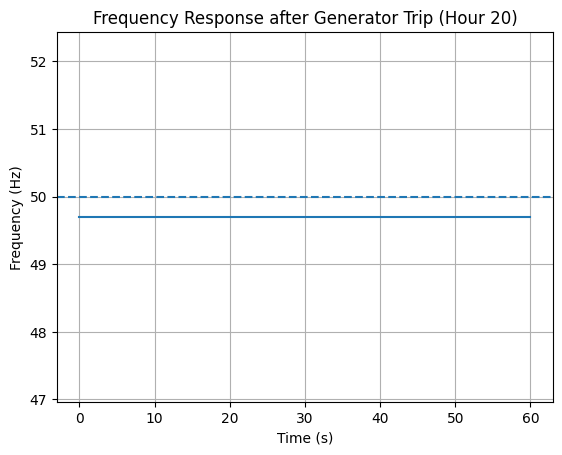

In [281]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 50.0
H_sys = 5.0
tau_gov = 3.0

t = np.linspace(0, 60, 1000)

P_response = total_pfr * (1 - np.exp(-t / tau_gov))
delta_f = (P_loss - P_response) / (2 * H_sys * 100)
freq_response = f0 - delta_f

f_nadir = np.min(freq_response)
f_ss = freq_response[-1]

print("\n========== FREQUENCY BLOCK 3: SINGLE-HOUR RESPONSE ==========")
print("Frequency nadir =", round(f_nadir, 4), "Hz")
print("Steady-state frequency =", round(f_ss, 4), "Hz")

f_min = 49.5
if f_nadir >= f_min:
    print("Status: AMAN")
else:
    print("Status: TIDAK AMAN")

plt.figure()
plt.plot(t, freq_response)
plt.axhline(50, linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response after Generator Trip (Hour {selected_hour})")
plt.grid()
plt.show()

Rekap Frekuensi Semua Jam

In [282]:
summary = []

test_hours = list(range(1, 25))

for th in test_hours:
    df_t = df_hourly[df_hourly["Hour"] == th].copy()

    dispatch = {}
    for g in gen_list:
        p = float(df_t[f"{g}_P"].iloc[0])
        u = float(df_t[f"{g}_U"].iloc[0])
        if u > 0.5 and p > 0:
            dispatch[g] = p

    trip_unit = max(dispatch, key=dispatch.get)
    P_loss = dispatch[trip_unit]

    total_reserve = sum(float(df_t[f"{g}_R"].iloc[0]) for g in gen_list)

    total_pfr = 0.0
    for g in gen_list:
        if g != trip_unit:
            total_pfr += float(df_t[f"{g}_PFR"].iloc[0])

    f0 = 50.0
    H_sys = 5.0
    tau_gov = 3.0

    t = np.linspace(0, 60, 1000)

    P_response = total_pfr * (1 - np.exp(-t / tau_gov))
    delta_f = (P_loss - P_response) / (2 * H_sys * 100)
    freq_response = f0 - delta_f

    f_nadir = np.min(freq_response)
    f_ss = freq_response[-1]

    net_deficit = P_loss - total_pfr
    pfr_ratio = total_pfr / P_loss if P_loss > 0 else 0

    summary.append([
        th,
        trip_unit,
        round(P_loss, 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(net_deficit, 2),
        round(pfr_ratio, 3) * 100,
        round(f_nadir, 4),
        round(f_ss, 4)
    ])

df_freq_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "Net Deficit (MW)",
    "PFR Ratio (%)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print("\n========== FREQUENCY BLOCK 4: ALL-HOUR SUMMARY ==========")
print(df_freq_summary.to_string(index=False))


========== FREQUENCY BLOCK 4: ALL-HOUR SUMMARY ==========
 t Unit Trip  Ploss (MW)  Total Reserve (MW)  Total PFR (MW)  Net Deficit (MW)  PFR Ratio (%)  f_nadir (Hz)  f_steady (Hz)
 1        G1       121.0               121.0             0.0             121.0            0.0        49.879         49.879
 2        G1       108.0               108.0             0.0             108.0            0.0        49.892         49.892
 3        G1       100.0               100.0             0.0             100.0            0.0        49.900         49.900
 4        G1        97.0                98.5             0.0              97.0            0.0        49.903         49.903
 5        G1       104.0               104.0             0.0             104.0            0.0        49.896         49.896
 6        G1       130.0               130.0             0.0             130.0            0.0        49.870         49.870
 7        G1       148.0               148.0             0.0             148.0  

Grafik Frekuensi

Grafik Net Deficit vs f nadir

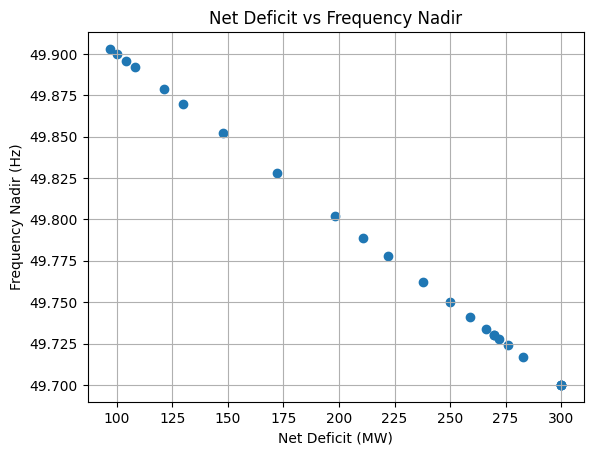

In [283]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_freq_summary["Net Deficit (MW)"], df_freq_summary["f_nadir (Hz)"])

plt.xlabel("Net Deficit (MW)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("Net Deficit vs Frequency Nadir")
plt.grid()

plt.show()

Grafik PFR Ratio vs f_nadir

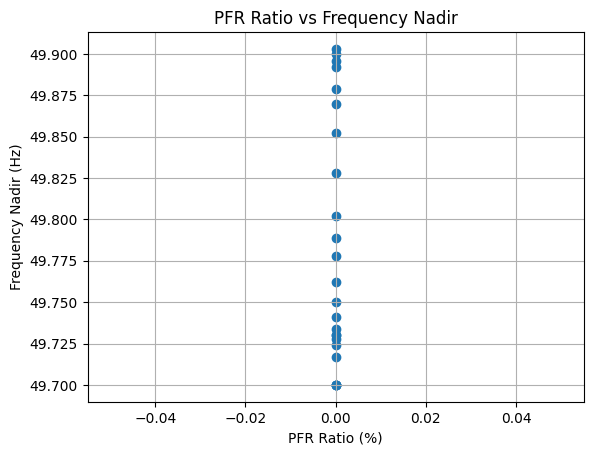

In [284]:
plt.figure()
plt.scatter(df_freq_summary["PFR Ratio (%)"], df_freq_summary["f_nadir (Hz)"])

plt.xlabel("PFR Ratio (%)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("PFR Ratio vs Frequency Nadir")
plt.grid()

plt.show()

Grafik per jam

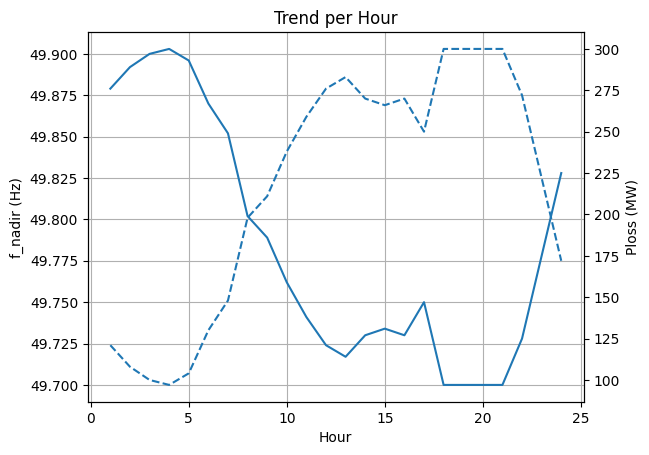

In [285]:
fig, ax1 = plt.subplots()

ax1.set_xlabel("Hour")
ax1.set_ylabel("f_nadir (Hz)")
ax1.plot(df_freq_summary["t"], df_freq_summary["f_nadir (Hz)"])
ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel("Ploss (MW)")
ax2.plot(df_freq_summary["t"], df_freq_summary["Ploss (MW)"], linestyle='--')

plt.title("Trend per Hour")
plt.show()

Grafik

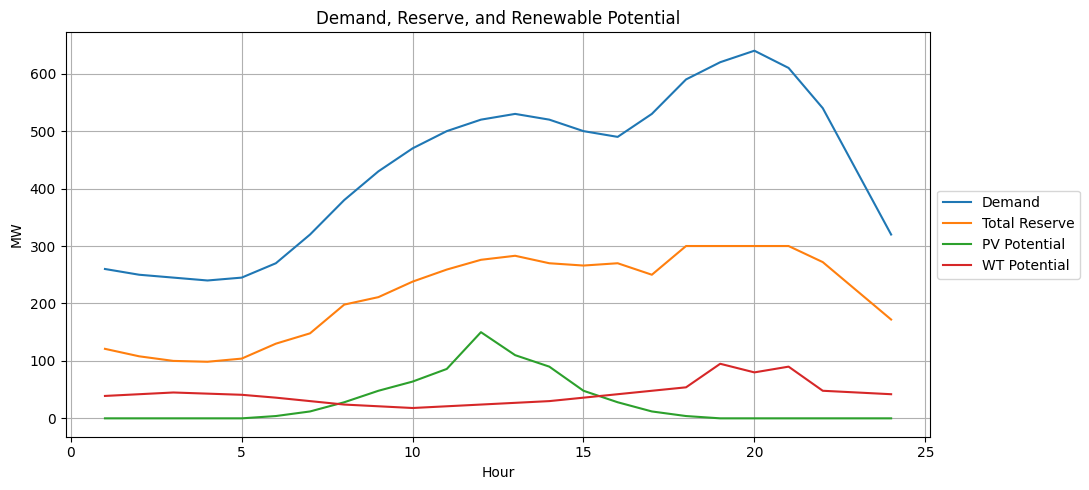

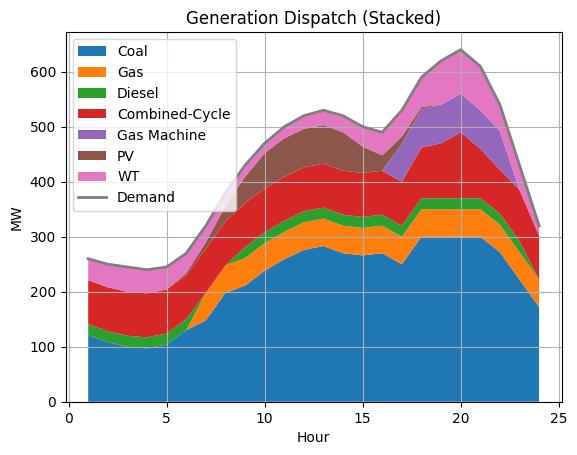

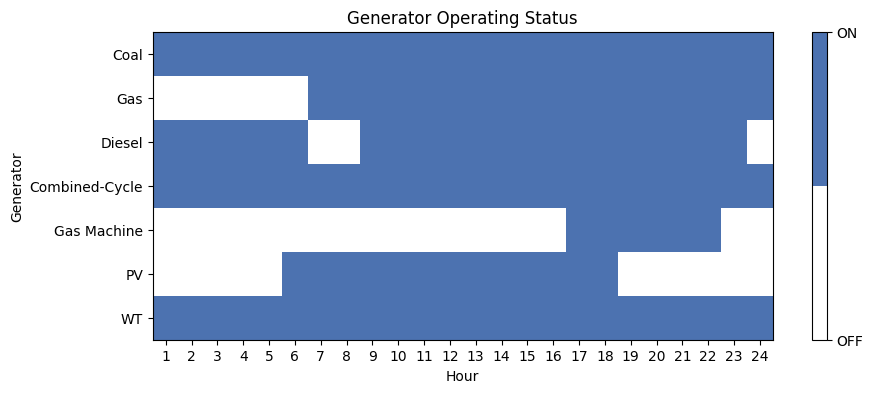

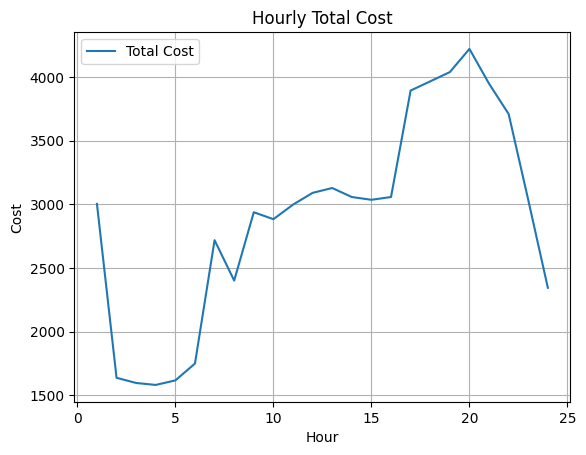

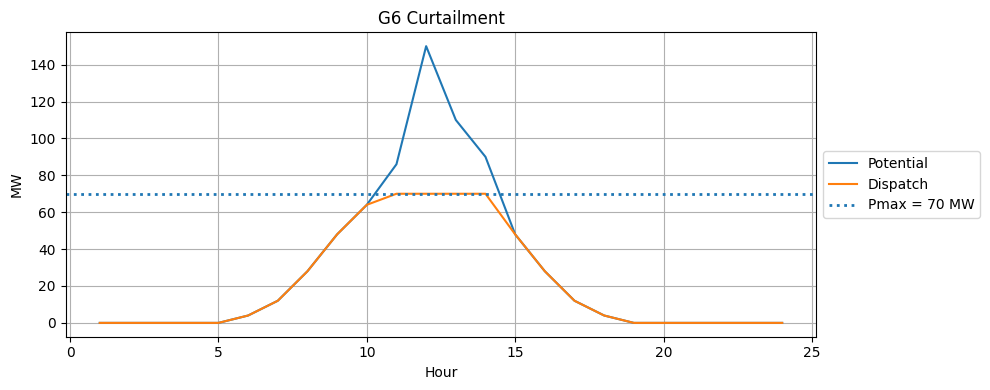

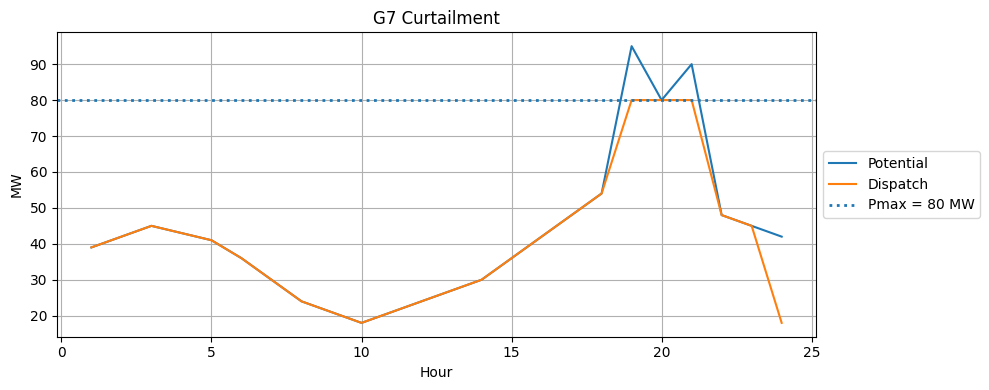

In [286]:
import matplotlib.pyplot as plt
# Mapping nama unit untuk tampilan
name_map = {
    "G1": "Coal",
    "G2": "Gas",
    "G3": "Diesel",
    "G4": "Combined-Cycle",
    "G5": "Gas Machine",
    "G6": "PV",
    "G7": "WT"
}

# Label Legend
plot_labels = [name_map.get(g, g) for g in model.G]

# ==============================================
# 1. DEMAND, RESERVE, PFR, PV/WT POTENTIAL
# ==============================================

hours = list(model.T)

demand = [value(model.Demand[t]) for t in model.T]

total_reserve = [
    sum(value(model.R[g, t]) for g in model.G)
    for t in model.T
]

reserve_req = [
    max(
        value(model.P[g, t])
        for g in model.G
        if Type[g] not in ["PV", "WT"]
    )
    for t in model.T
]

if use_pfr:
    total_pfr = [
        sum(value(model.R_pfr[g, t]) for g in model.G)
        for t in model.T
    ]
    pfr_req = [
        value(model.PFRReq[t])
        for t in model.T
    ]
else:
    total_pfr = [0 for t in model.T]
    pfr_req = [0 for t in model.T]

pv_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "PV")
    for t in model.T
]

wt_potential = [
    sum(value(model.RenewPotential[g, t]) for g in model.G if Type[g] == "WT")
    for t in model.T
]

plt.figure(figsize=(11, 5))
plt.plot(hours, demand, label="Demand")
plt.plot(hours, total_reserve, label="Total Reserve")
#plt.plot(hours, reserve_req, linestyle="--", label="Reserve Requirement")
#plt.plot(hours, total_pfr, label="Total PFR")
#plt.plot(hours, pfr_req, linestyle="--", label="PFR Requirement")
plt.plot(hours, pv_potential, label="PV Potential")
plt.plot(hours, wt_potential, label="WT Potential")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Demand, Reserve, and Renewable Potential")
#plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid()
plt.show()

#plt.figure()
#plt.plot(df_hourly["Hour"], df_hourly["Demand"], label="Demand")
#plt.plot(df_hourly["Hour"], df_hourly["Total_Power"], label="Total Generation")

#plt.xlabel("Hour")
#plt.ylabel("MW")
#plt.title("Load vs Generation")
#plt.legend()
#plt.grid()
#plt.show()

# ===============================
# 2. DISPATCH PER UNIT (STACKED)
# ===============================
gen_cols = [f"{g}_P" for g in model.G]



plt.figure()
plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

# Overlay demand
plt.plot(df_hourly["Hour"], df_hourly["Demand"], linewidth=2, label="Demand")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# 3. STATUS UNIT (ON/OFF)
# ===============================
import numpy as np
from matplotlib.colors import ListedColormap
from pyomo.environ import value

gen_status_matrix = []

for g in model.G:
    gen_status_matrix.append([
        1 if value(model.P[g, t]) > 1e-4 else 0
        for t in model.T
    ])

# matrix status (0/1)
matrix = np.array(gen_status_matrix)

# colormap: 0 = putih, 1 = biru (bisa diganti)
cmap = ListedColormap(["white", "#4C72B0"])  # biru soft

plt.figure(figsize=(10, 4))

plt.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0, vmax=1
)

plt.xticks(range(len(list(model.T))), list(model.T))
plt.yticks(range(len(list(model.G))), [name_map.get(g, g) for g in model.G])

plt.xlabel("Hour")
plt.ylabel("Generator")
plt.title("Generator Operating Status")

# colorbar khusus biner
cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(["OFF", "ON"])

plt.show()

# ===============================
# 4. TOTAL COST PER HOUR
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Total Cost"], label="Total Cost")

plt.xlabel("Hour")
plt.ylabel("Cost")
plt.title("Hourly Total Cost")
plt.legend()
plt.grid()
plt.show()

# Visual Curtailment
for g in model.G:
    if Type[g] in ["PV", "WT"]:
        potential = [value(model.RenewPotential[g, t]) for t in model.T]
        dispatch  = [value(model.P[g, t]) for t in model.T]
        #curt      = [value(model.Curt[g, t]) for t in model.T]
        pmax_g    = value(model.Pmax[g])

        plt.figure(figsize=(10,4))
        plt.plot(model.T, potential, label="Potential")
        plt.plot(model.T, dispatch, label="Dispatch")
        #plt.plot(model.T, curt, linestyle="--", label="Curtailment")

        # Kapasitas maksimum terpasang
        plt.axhline(
            y=pmax_g,
            linestyle=":",
            linewidth=2,
            label=f"Pmax = {pmax_g} MW"
        )

        plt.title(f"{g} Curtailment")
        plt.xlabel("Hour")
        plt.ylabel("MW")
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
        plt.grid()
        plt.tight_layout()
        plt.show()


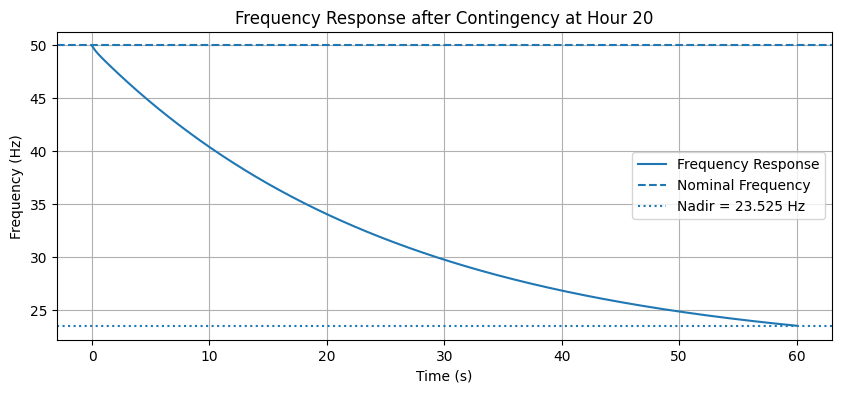

In [287]:
plt.figure(figsize=(10, 4))
plt.plot(time, freq, label="Frequency Response")
plt.axhline(f0, linestyle="--", label="Nominal Frequency")
plt.axhline(nadir, linestyle=":", label=f"Nadir = {nadir:.3f} Hz")

plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response after Contingency at Hour {t_uc}")
plt.legend()
plt.grid()
plt.show()